In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, 'src')):
    root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(root_dir)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,           
    'axes.spines.top': False,     
    'axes.spines.right': False,  
    'font.family': 'serif'        
})

COLORS = ['#3498db', '#e74c3c']

In [ ]:
RAW_DATA_PATH = os.path.join(os.getcwd(), "data", "raw", "sms_spam_indo.csv")
df = pd.read_csv(RAW_DATA_PATH)

total_rows = len(df)
missing_values = df.isnull().sum().sum()
duplicates = df.duplicated(subset=['Pesan']).sum()
class_counts = df['Kategori'].value_counts()
class_ratios = df['Kategori'].value_counts(normalize=True) * 100

eda_summary = pd.DataFrame({
    'Metrik': ['Total Sampel', 'Nilai Hilang (Missing)', 'Duplikasi Teks', 'Sampel Normal (Ham)', 'Sampel Penipuan (Spam)'],
    'Nilai': [total_rows, missing_values, duplicates, class_counts.get('normal', 0), class_counts.get('spam', 0)],
    'Persentase': ['100%', f"{(missing_values/total_rows)*100:.2f}%", f"{(duplicates/total_rows)*100:.2f}%", f"{class_ratios.get('normal', 0):.1f}%", f"{class_ratios.get('spam', 0):.1f}%"]
})

display(eda_summary)

,Metrik,Nilai,Persentase
0,Total Sampel,1143,100%
1,Nilai Hilang (Missing),0,0.00%
2,Duplikasi Teks,1,0.09%
3,Sampel Normal (Ham),0,0.0%
4,Sampel Penipuan (Spam),574,50.2%


C:\Users\10\AppData\Local\Temp\ipykernel_5860\3559079056.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Kategori', palette=COLORS, ax=axes[0], edgecolor='black')


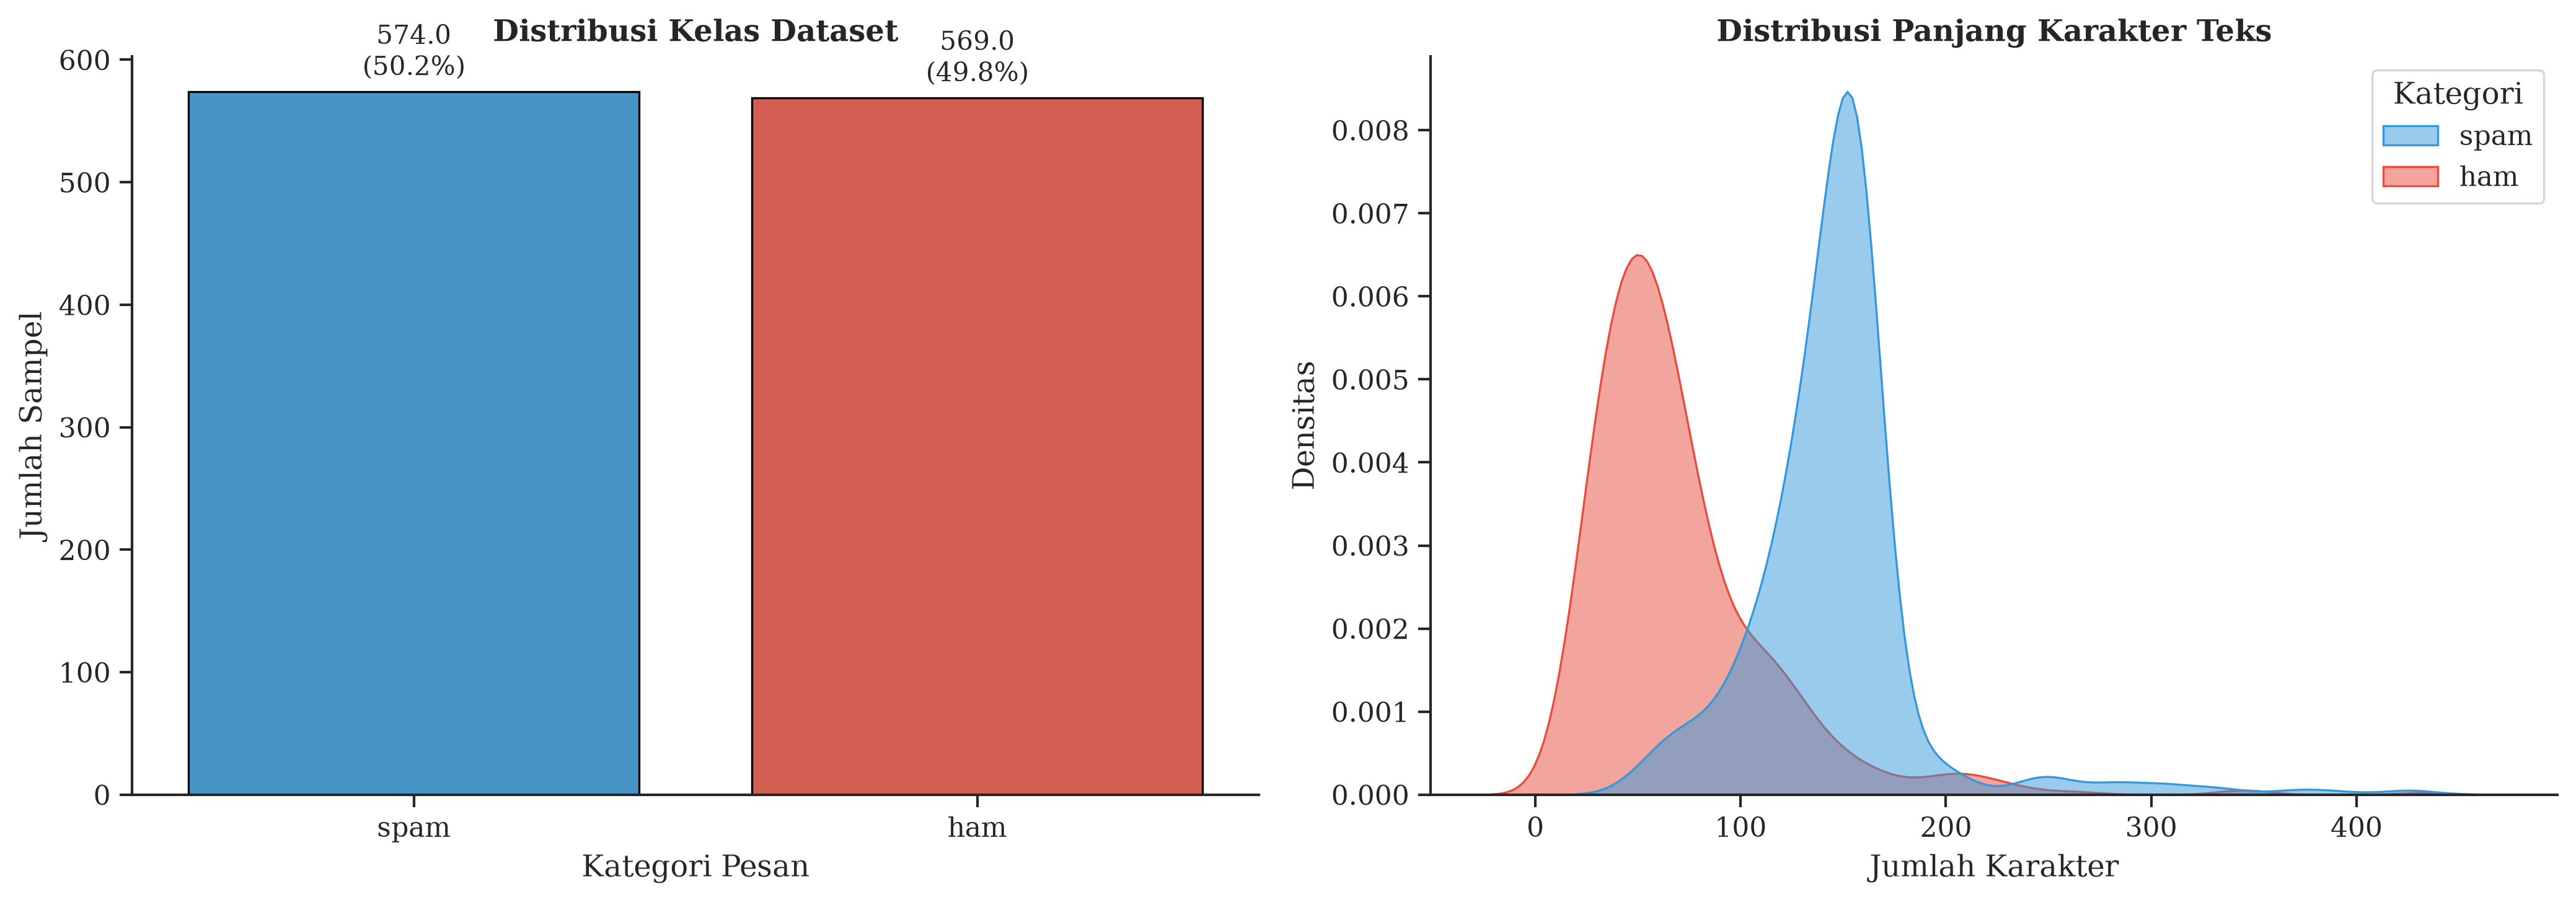

Karakter                          Kata                     
             mean median min  max    std   mean median min max   std
Kategori                                                            
ham         70.54   59.0  13  434  46.23  12.12   11.0   2  63  7.23
spam       146.60  149.0  46  431  44.19  21.22   20.0   5  62  6.99

In [ ]:
df['Karakter'] = df['Pesan'].apply(len)
df['Kata'] = df['Pesan'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Kategori', palette=COLORS, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Kelas Dataset', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kategori Pesan')

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height}\n({(height/total_rows)*100:.1f}%)', 
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points", 
                     ha='center', va='bottom', fontsize=10)

sns.kdeplot(data=df, x='Karakter', hue='Kategori', fill=True, palette=COLORS, ax=axes[1], alpha=0.5)
axes[1].set_title('Distribusi Panjang Karakter Teks', fontweight='bold')
axes[1].set_ylabel('Densitas')
axes[1].set_xlabel('Jumlah Karakter')

plt.tight_layout()
plt.show()

text_stats = df.groupby('Kategori')[['Karakter', 'Kata']].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
display(text_stats)

In [46]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

def evaluate_classification(df, model_name, technique):
    """
    Melatih dan mengevaluasi XGBoost menggunakan 5-Fold Cross Validation.
    """
    X = df['Pesan'].astype(str)
    y = df['Kategori']
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    vectorizer = TfidfVectorizer(max_features=5000)
    X_tfidf = vectorizer.fit_transform(X)
    
    xgb = XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        random_state=42,
        eval_metric='logloss'
    )
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': [], 'ROC-AUC': []}
    
    for train_idx, test_idx in skf.split(X_tfidf, y_encoded):
        X_train, X_test = X_tfidf[train_idx], X_tfidf[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
        
        xgb.fit(X_train, y_train)
        y_pred = xgb.predict(X_test)
        y_prob = xgb.predict_proba(X_test)[:, 1]
        
        metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
        metrics['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
        metrics['Recall'].append(recall_score(y_test, y_pred, zero_division=0))
        metrics['F1-Score'].append(f1_score(y_test, y_pred, zero_division=0))
        metrics['ROC-AUC'].append(roc_auc_score(y_test, y_prob))
        
    return {
        'Model': model_name,
        'Technique': technique,
        'Accuracy': np.mean(metrics['Accuracy']),
        'Precision': np.mean(metrics['Precision']),
        'Recall': np.mean(metrics['Recall']),
        'F1-Score': np.mean(metrics['F1-Score']),
        'ROC-AUC': np.mean(metrics['ROC-AUC'])
    }

In [63]:
import glob
import os
import pandas as pd

TIMESTAMP_FOLDER = "20260831151426"  

print("Evaluating Baseline...")
baseline_df = df.copy() 
results_list = [evaluate_classification(baseline_df, 'Baseline', 'None')]

synthetic_dir = os.path.join(root_dir, "data", "augmented", TIMESTAMP_FOLDER, "synthetic")

if not os.path.exists(synthetic_dir):
    print(f"Error: Directory not found -> {synthetic_dir}")
else:
    synthetic_files = glob.glob(os.path.join(synthetic_dir, "synthetic_*.csv"))
    print(f"Found {len(synthetic_files)} scenarios in {TIMESTAMP_FOLDER}. Starting evaluation...")

    for file_path in synthetic_files:
        file_name = os.path.basename(file_path).replace("synthetic_", "").replace(".csv", "")
        parts = file_name.split("_")
        technique = parts[-1] 
        model_name = "_".join(parts[:-1])
        
        df_syn = pd.read_csv(file_path)
        
        if 'Kategori' in df_syn.columns and 'Pesan' in df_syn.columns:
            df_syn = df_syn[['Kategori', 'Pesan']]
            
        merged_df = pd.concat([baseline_df, df_syn], ignore_index=True)
        
        print(f"Processing: {model_name} | {technique}")
        res = evaluate_classification(merged_df, model_name, technique)
        results_list.append(res)

df_results = pd.DataFrame(results_list)

cols = ['Model', 'Technique', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_results = df_results[cols]

display(df_results.round(4).style.background_gradient(subset=['F1-Score', 'Recall', 'ROC-AUC'], cmap='Blues'))

Evaluating Baseline...
Found 12 scenarios in 20260831151426. Starting evaluation...
Processing: GPT_3.5_Turbo | few-shot
Processing: GPT_3.5_Turbo | role-prompting
Processing: GPT_3.5_Turbo | zero-shot
Processing: GPT_4.1 | few-shot
Processing: GPT_4.1 | role-prompting
Processing: GPT_4.1 | zero-shot
Processing: LLaMA2_7B | few-shot
Processing: LLaMA2_7B | role-prompting
Processing: LLaMA2_7B | zero-shot
Processing: LLaMA3_8B | few-shot
Processing: LLaMA3_8B | role-prompting
Processing: LLaMA3_8B | zero-shot


,Model,Technique,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,None,0.944900,0.964200,0.925100,0.944000,0.988700
1,GPT_3.5_Turbo,few-shot,0.982600,0.989400,0.989700,0.989600,0.995800
2,GPT_3.5_Turbo,role-prompting,0.978300,0.985900,0.988000,0.987000,0.995600
3,GPT_3.5_Turbo,zero-shot,0.980200,0.986900,0.989300,0.988100,0.994300
4,GPT_4.1,few-shot,0.983800,0.988700,0.991800,0.990300,0.996200
5,GPT_4.1,role-prompting,0.980400,0.987700,0.988800,0.988200,0.996000
6,GPT_4.1,zero-shot,0.982000,0.988400,0.990100,0.989200,0.996000
7,LLaMA2_7B,few-shot,0.980200,0.992600,0.983600,0.988000,0.997200
8,LLaMA2_7B,role-prompting,0.978700,0.993300,0.981100,0.987100,0.997000
9,LLaMA2_7B,zero-shot,0.977100,0.990100,0.982200,0.986100,0.996200


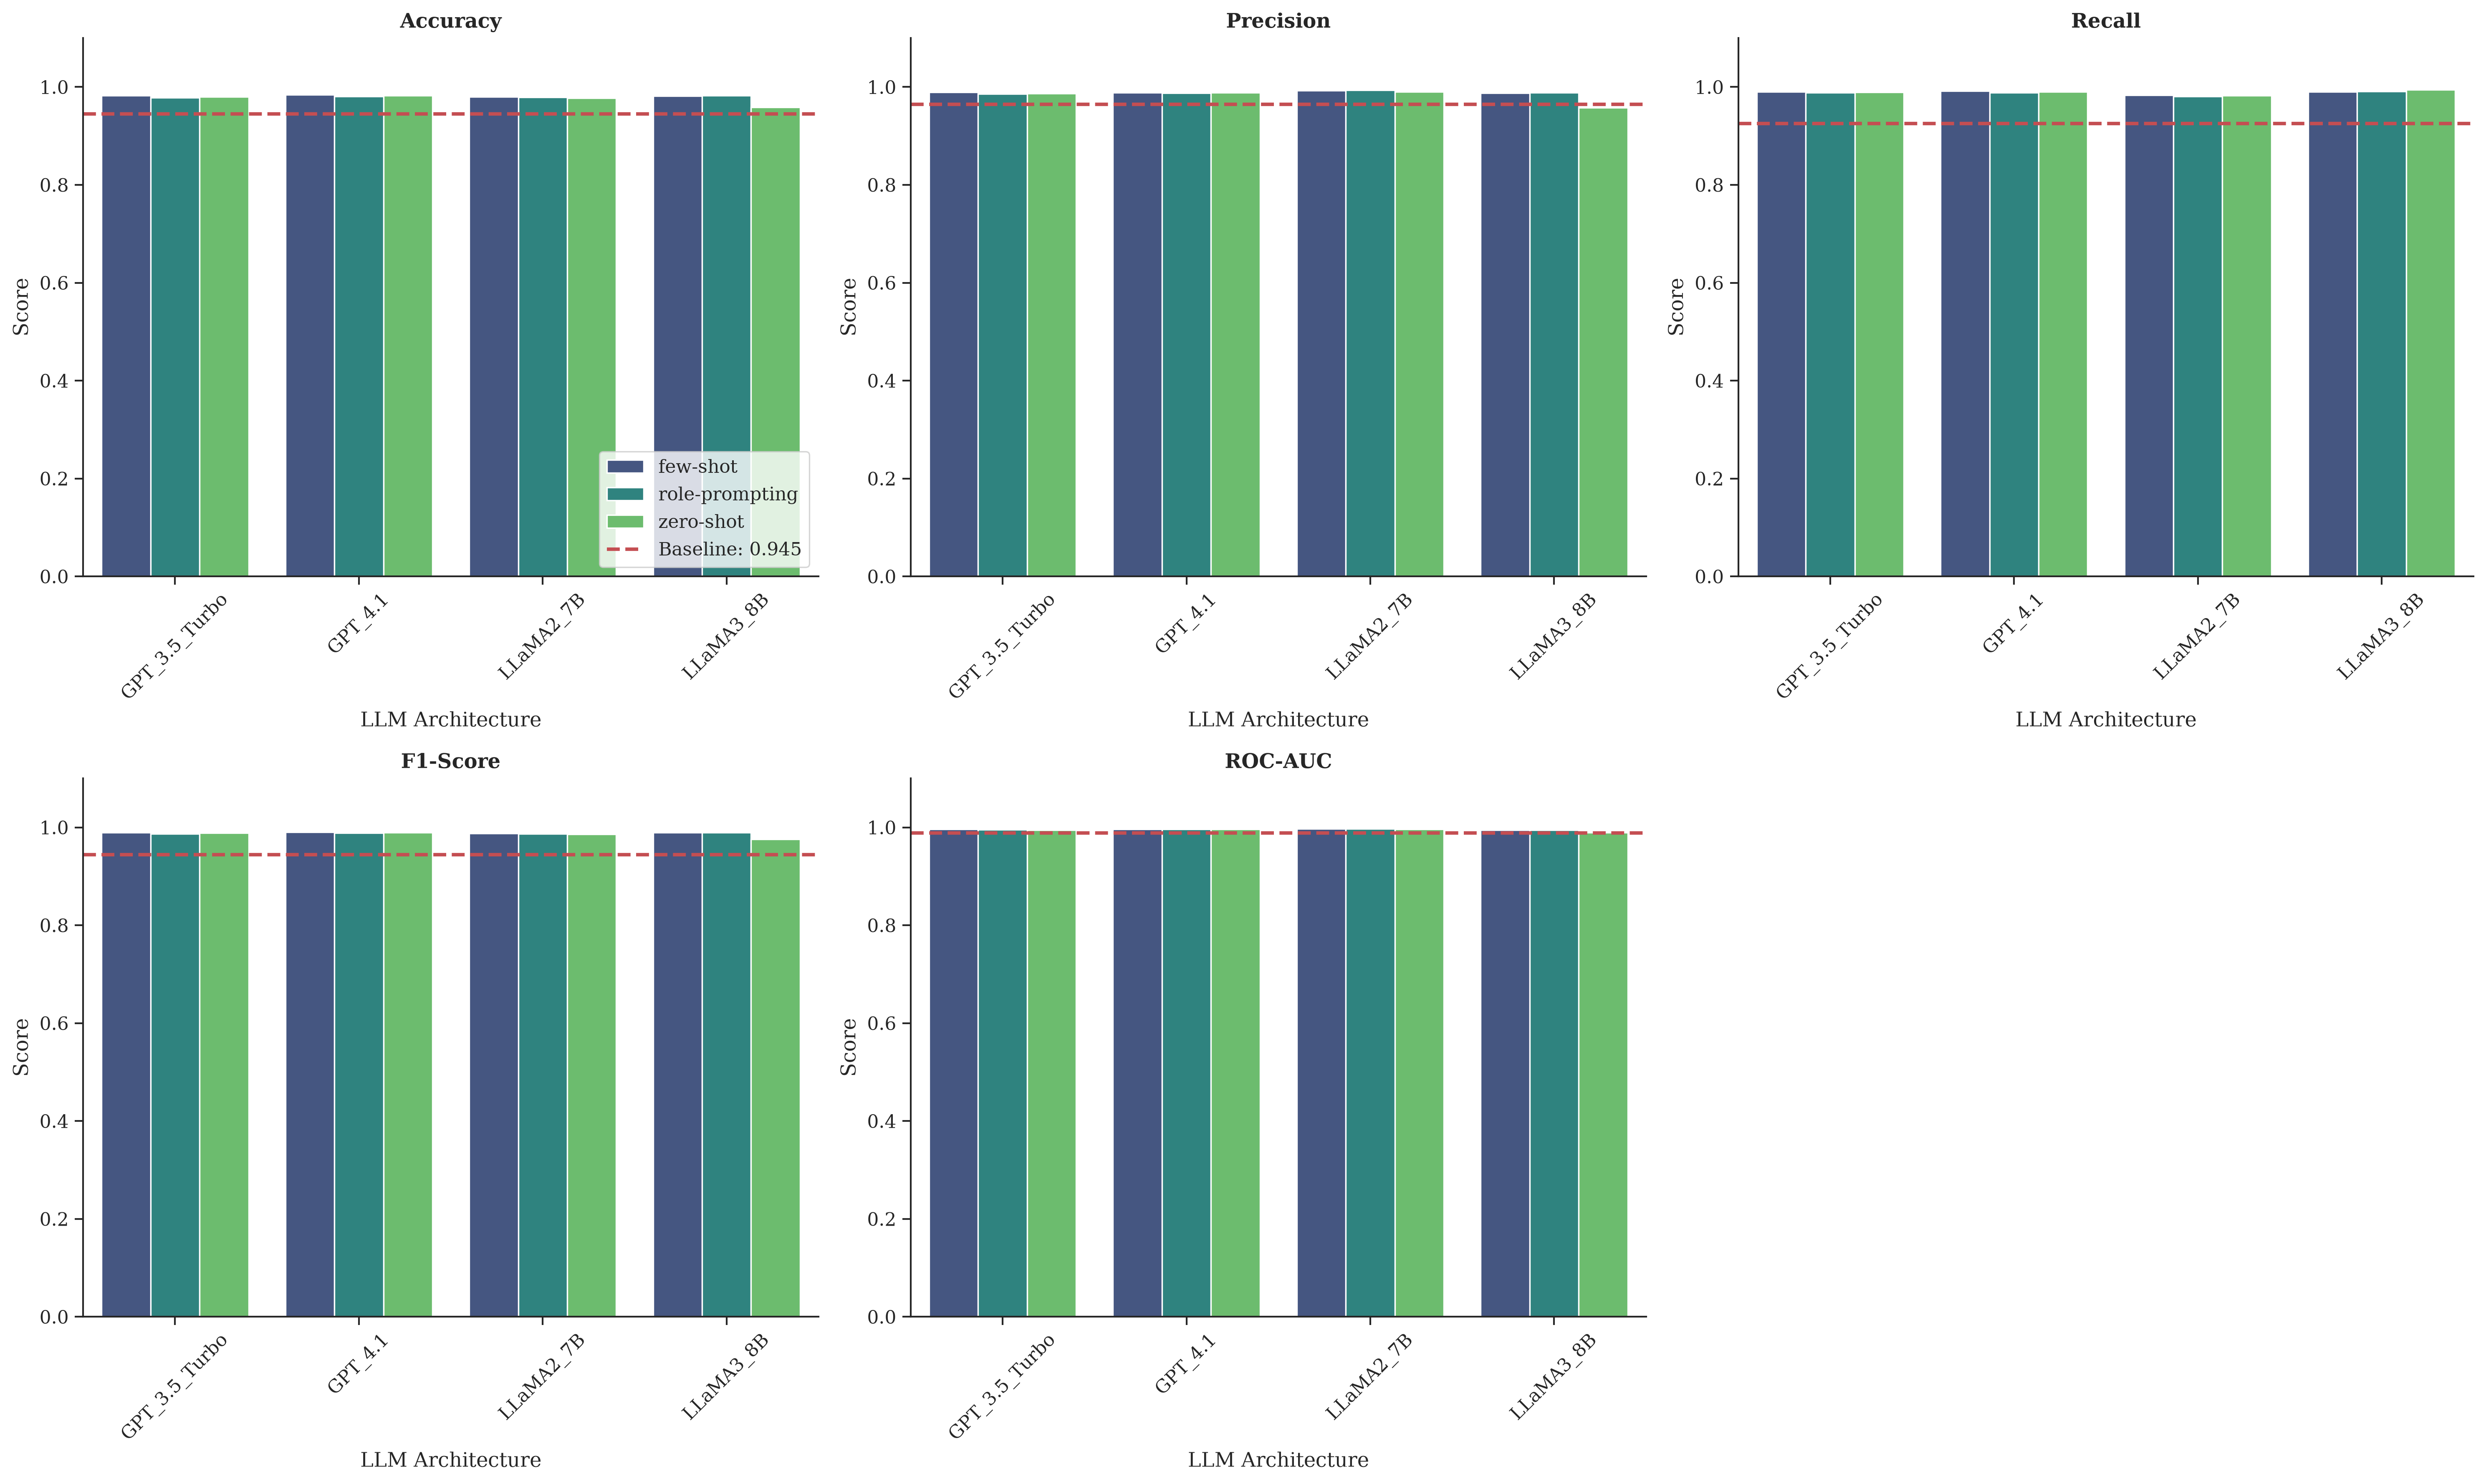

In [64]:
plot_df = df_results[df_results['Model'] != 'Baseline']
baseline_metrics = df_results[df_results['Model'] == 'Baseline'].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten() 

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]
    
    if not plot_df.empty:
        sns.barplot(data=plot_df, x='Model', y=metric, hue='Technique', ax=ax, palette='viridis')
        
    ax.axhline(y=baseline_metrics[metric], color='r', linestyle='--', linewidth=2, label=f'Baseline: {baseline_metrics[metric]:.3f}')
    
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Score')
    ax.set_xlabel('LLM Architecture')
    
    legend = ax.get_legend()
    if i == 0:
        if legend is not None:
            ax.legend(loc='lower right')
    else:
        if legend is not None:
            legend.remove()

axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

In [68]:
import os
import glob
import pandas as pd
from src.evaluator import TextEvaluator

print("Initializing NLP Evaluator (Loading BERT and ROUGE models)...")
evaluator = TextEvaluator()

quality_results = []
log_dir = os.path.join(root_dir, "data", "augmented", TIMESTAMP_FOLDER, "augmented_log")

if not os.path.exists(log_dir):
    print(f"Error: Log directory not found -> {log_dir}")
else:
    log_files = glob.glob(os.path.join(log_dir, "log_*.csv"))
    print(f"Found {len(log_files)} log files for NLP evaluation.")
    
    for file_path in log_files:
        file_name = os.path.basename(file_path).replace("log_", "").replace(".csv", "")
        parts = file_name.split("_")
        technique = parts[-1] 
        model_name = "_".join(parts[:-1])
        
        df_log = pd.read_csv(file_path)
        
        original_col = 'original_text' if 'original_text' in df_log.columns else df_log.columns[0]
        synthetic_col = 'augmented_text' if 'augmented_text' in df_log.columns else df_log.columns[1]
        
        df_synthetic = pd.DataFrame({'Pesan': df_log[synthetic_col]})
        original_texts = df_log[original_col].tolist()
        
        print(f"Evaluating text quality for: {model_name} | {technique}")
        
        df_scored, avg_scores = evaluator.evaluate_dataframe(df_synthetic, original_texts)
        
        quality_results.append({
            'Model': model_name,
            'Technique': technique,
            'BERTScore': avg_scores['Avg_BERT_Score'],
            'BLEU': avg_scores['Avg_BLEU'],
            'ROUGE-L': avg_scores['Avg_ROUGE_L']
            # 'Cosine Similarity': avg_scores.get('Avg_Cosine_Sim', None) # Ready for future implementation
        })

df_quality = pd.DataFrame(quality_results)
if not df_quality.empty:
    display(df_quality.round(4).style.background_gradient(cmap='Greens'))

Initializing NLP Evaluator (Loading BERT and ROUGE models)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9014.94it/s]


Found 12 log files for NLP evaluation.
Evaluating text quality for: GPT_3.5_Turbo | few-shot


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9045.33it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating text quality for: GPT_3.5_Turbo | role-prompting


...

Evaluating text quality for: LLaMA3_8B | role-prompting


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6216.00it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating text quality for: LLaMA3_8B | zero-shot


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6120.38it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Model,Technique,BERTScore,BLEU,ROUGE-L
0,GPT_3.5_Turbo,few-shot,0.828900,0.265100,0.622400
1,GPT_3.5_Turbo,role-prompting,0.857000,0.332000,0.620800
2,GPT_3.5_Turbo,zero-shot,0.854300,0.358500,0.666800
3,GPT_4.1,few-shot,0.806900,0.151600,0.528000
4,GPT_4.1,role-prompting,0.805900,0.126100,0.495500
5,GPT_4.1,zero-shot,0.828900,0.181100,0.575200
6,LLaMA2_7B,few-shot,0.705700,0.174600,0.331500
7,LLaMA2_7B,role-prompting,0.730800,0.261700,0.429900
8,LLaMA2_7B,zero-shot,0.875000,0.534200,0.761400
9,LLaMA3_8B,few-shot,0.851900,0.429100,0.688000


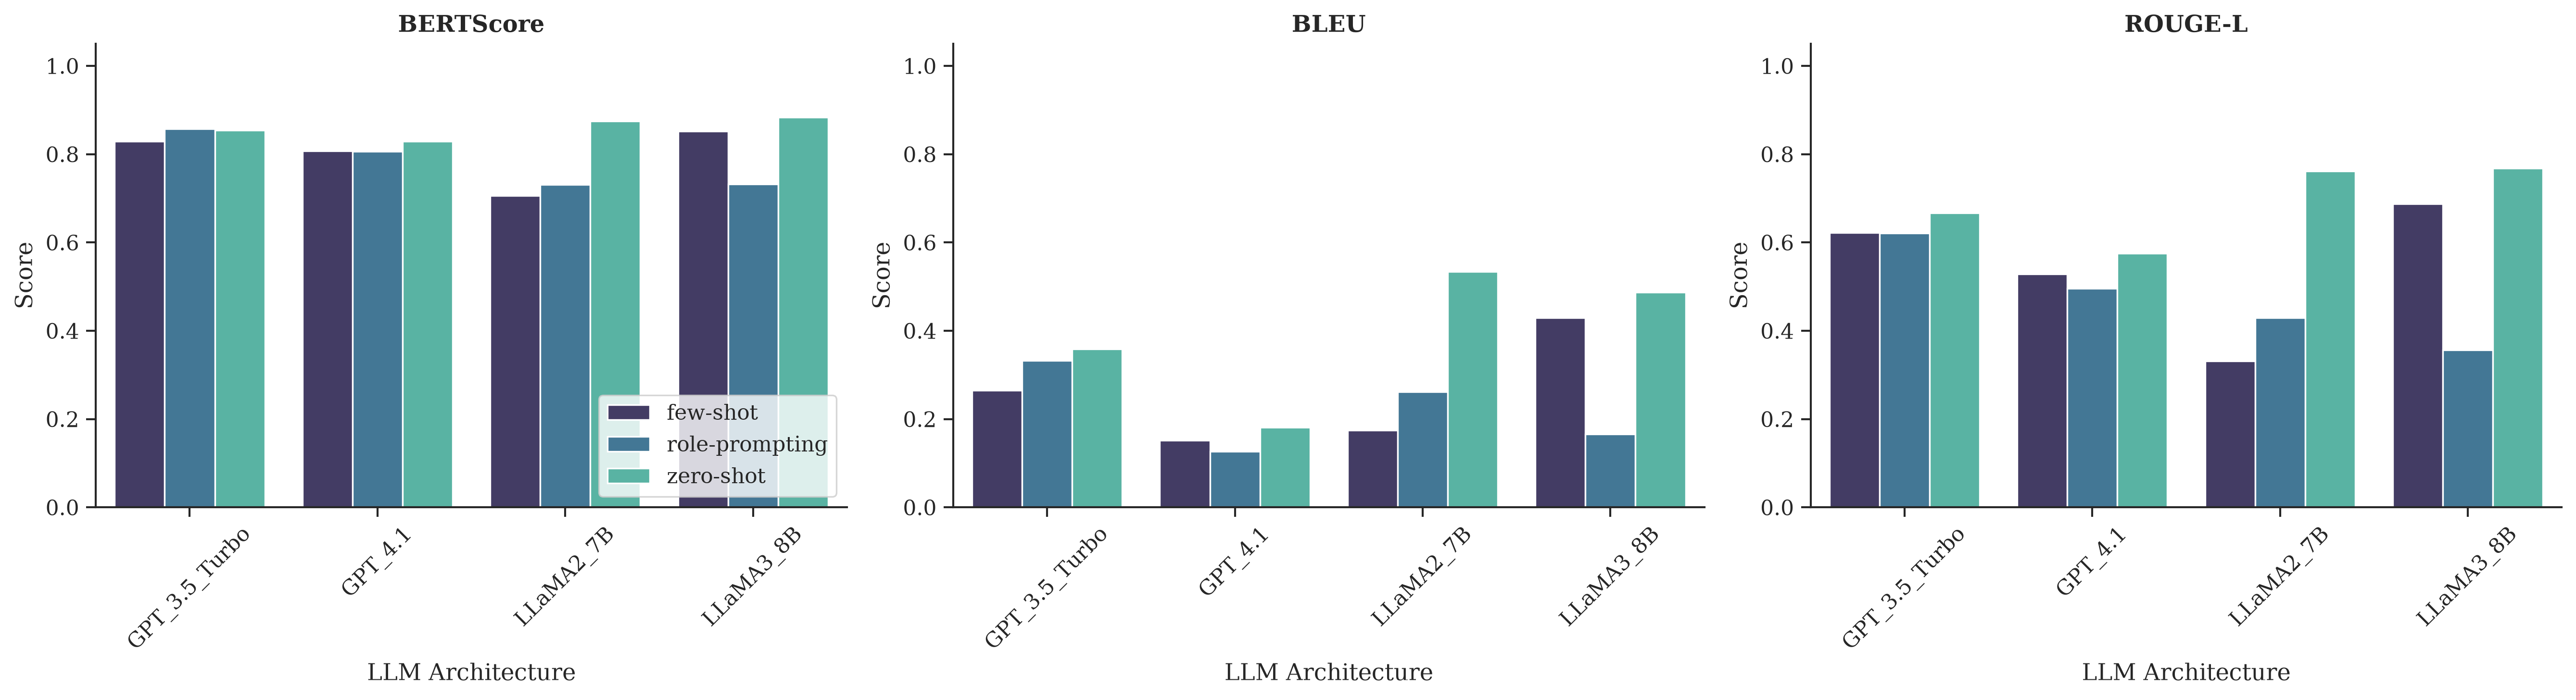

In [67]:
if not df_quality.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    nlp_metrics = ['BERTScore', 'BLEU', 'ROUGE-L']
    
    for i, metric in enumerate(nlp_metrics):
        sns.barplot(data=df_quality, x='Model', y=metric, hue='Technique', ax=axes[i], palette='mako')
        
        axes[i].set_title(metric, fontweight='bold')
        axes[i].set_ylim(0, 1.05) # Text metrics are strictly 0.0 to 1.0
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Score')
        axes[i].set_xlabel('LLM Architecture')
        
        legend = axes[i].get_legend()
        if i == 0:
            if legend is not None:
                axes[i].legend(loc='lower right')
        else:
            if legend is not None:
                legend.remove()

    plt.tight_layout()
    plt.show()